# Prompt-Based Image Segmentation with SAM3

In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .
!pip install -e ".[notebooks]"
!pip install -e ".[train,dev]"

In [1]:
from huggingface_hub import login
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
login(token=hf_token)

## **1.** Input

In [2]:
!wget "https://raw.githubusercontent.com/paulinamoskwa/notebooks/main/data/ilves_kookoo_20251212.mp4" -O ilves_kookoo.mp4

--2025-12-14 19:16:25--  https://raw.githubusercontent.com/paulinamoskwa/notebooks/main/data/ilves_kookoo_20251212.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11478452 (11M) [application/octet-stream]
Saving to: ‘ilves_kookoo.mp4’

ilves_kookoo.mp4    100%[===================>]  10.95M  --.-KB/s    in 0.07s   

2025-12-14 19:16:26 (160 MB/s) - ‘ilves_kookoo.mp4’ saved [11478452/11478452]



In [4]:
import cv2
import numpy as np
import os

video_path = "/content/ilves_kookoo.mp4"
output_dir = "/content/frames"
N_frames = 10

os.makedirs(output_dir, exist_ok=True)

# Open video
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Get N_frames indices evenly spaced from 0 to total_frames-1
frame_indices = np.linspace(0, total_frames-1, N_frames, dtype=int)

for i, idx in enumerate(frame_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        output_path = os.path.join(output_dir, f"frame_{i:03d}.png")
        cv2.imwrite(output_path, frame)
        print(f"Saved frame {idx} to: {output_path}")
    else:
        print(f"Error reading frame {idx}")

cap.release()


Saved frame 0 to: /content/frames/frame_000.png
Saved frame 75 to: /content/frames/frame_001.png
Saved frame 151 to: /content/frames/frame_002.png
Saved frame 226 to: /content/frames/frame_003.png
Saved frame 302 to: /content/frames/frame_004.png
Saved frame 377 to: /content/frames/frame_005.png
Saved frame 453 to: /content/frames/frame_006.png
Saved frame 528 to: /content/frames/frame_007.png
Saved frame 604 to: /content/frames/frame_008.png
Saved frame 680 to: /content/frames/frame_009.png


## **2.** Model

In [3]:
import torch
from PIL import Image
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

bpe_path = "/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
model = build_sam3_image_model(bpe_path=bpe_path)
processor = Sam3Processor(model)

config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## **3.** Inference - Annotations in COCO format

In [7]:
import os
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pycocotools import mask as mask_utils

frame_paths = sorted(os.listdir("/content/frames"))
frame_paths = [os.path.join("/content/frames", f) for f in frame_paths]

coco_dataset = {
    "images": [],
    "annotations": [],
    "categories": [{"id": 1, "name": "hockey_player"}]
}

# Unique annotation ID
ann_id = 1

for img_id, frame_path in enumerate(frame_paths, start=1):
    image = Image.open(frame_path)
    img_w, img_h = image.size

    # Add image info
    coco_dataset["images"].append({
        "id": img_id,
        "width": img_w,
        "height": img_h,
        "file_name": os.path.basename(frame_path)
    })

    # SAM inference
    inference_state = processor.set_image(image)
    output = processor.set_text_prompt(state=inference_state, prompt="hockey player on the field")
    masks, boxes, scores = output["masks"], output["boxes"], output["scores"]

    for idx in range(len(masks)):
        mask = masks[idx].cpu().numpy() if hasattr(masks[idx], "cpu") else masks[idx]
        mask = mask.squeeze()
        mask_uint8 = (mask > 0.5).astype(np.uint8)

        # Skip empty masks
        if mask_uint8.sum() == 0:
            continue

        # Convert mask to  Run-Length Encoding  (RLE)
        #   For 1D mask like:
        #   [0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1]
        #   instead of storing all 11 values, RLE stores:
        #   "3 zeros, 4 ones, 2 zeros, 2 ones"
        rle = mask_utils.encode(np.asfortranarray(mask_uint8))
        rle["counts"] = rle["counts"].decode("utf-8")

        # Get bounding box [x, y, width, height]
        ys, xs = np.where(mask_uint8)
        x_min, x_max = xs.min(), xs.max()
        y_min, y_max = ys.min(), ys.max()
        bbox = [int(x_min), int(y_min), int(x_max - x_min + 1), int(y_max - y_min + 1)]

        coco_dataset["annotations"].append({
            "id": ann_id,
            "image_id": img_id,
            "category_id": 1,
            "bbox": bbox,
            "segmentation": rle,
            "area": int(mask_uint8.sum()),
            "iscrowd": 0,
            "score": float(scores[idx]) if scores is not None else 1.0
        })
        ann_id += 1

# Save
os.makedirs("/content/annotations", exist_ok=True)
with open("/content/annotations/train.json", "w") as f:
    json.dump(coco_dataset, f)

print(f"COCO annotations saved: {len(coco_dataset['images'])} images, {len(coco_dataset['annotations'])} annotations")

COCO annotations saved: 10 images, 97 annotations


In [9]:
coco_dataset.keys()

dict_keys(['images', 'annotations', 'categories'])

In [10]:
coco_dataset['categories']

[{'id': 1, 'name': 'hockey_player'}]

In [12]:
coco_dataset['annotations'][0].keys()

dict_keys(['id', 'image_id', 'category_id', 'bbox', 'segmentation', 'area', 'iscrowd', 'score'])

In [14]:
coco_dataset['images'][0]

{'id': 1, 'width': 1280, 'height': 720, 'file_name': 'frame_000.png'}

## **4.** Visualization

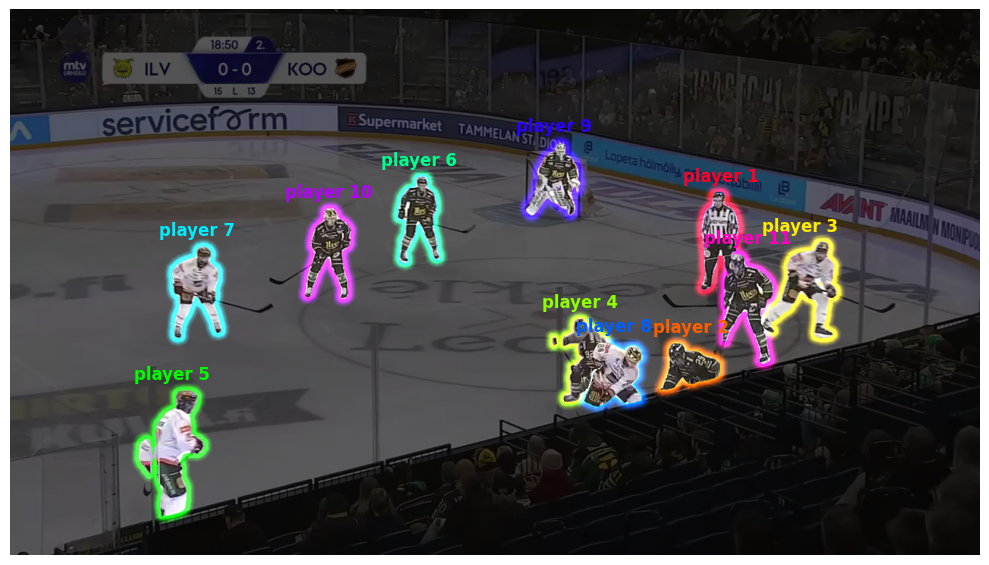

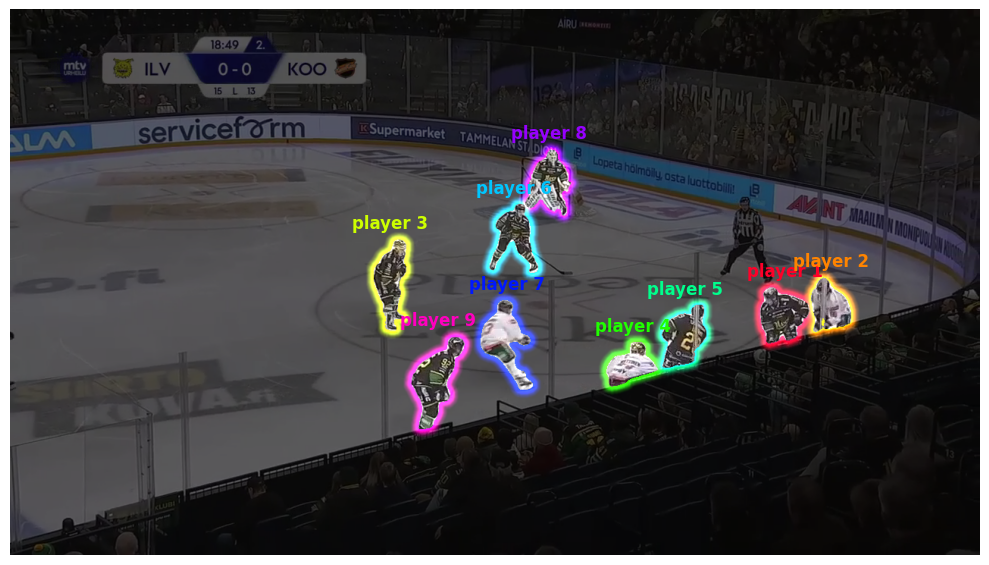

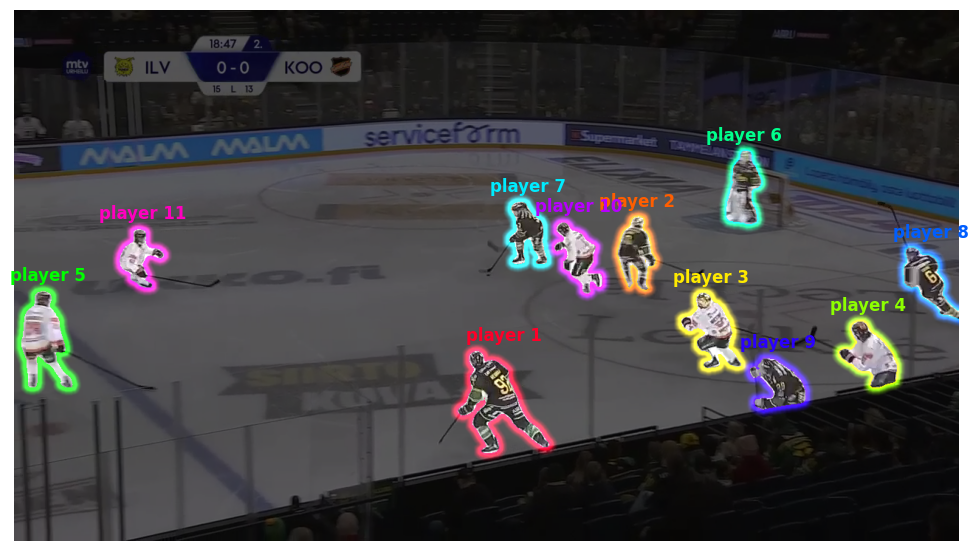

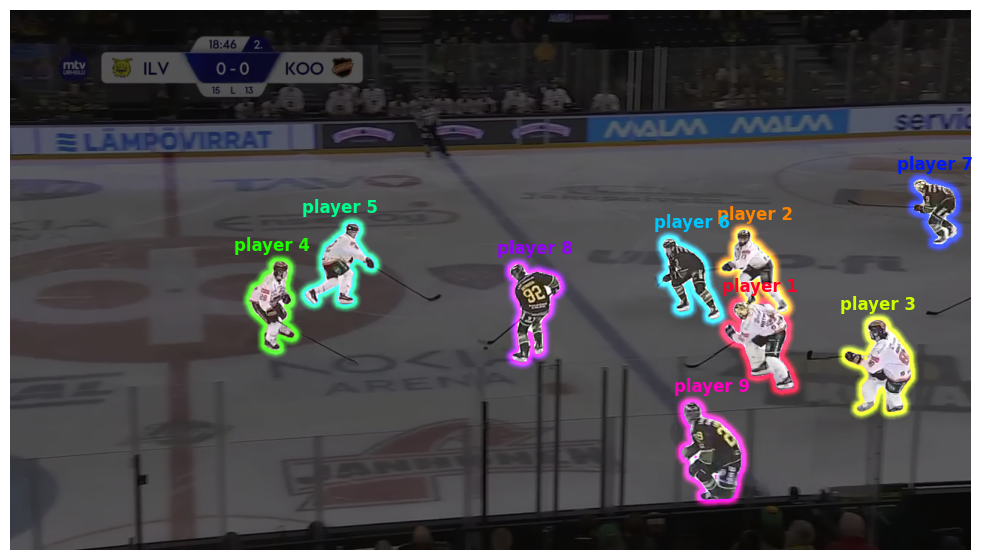

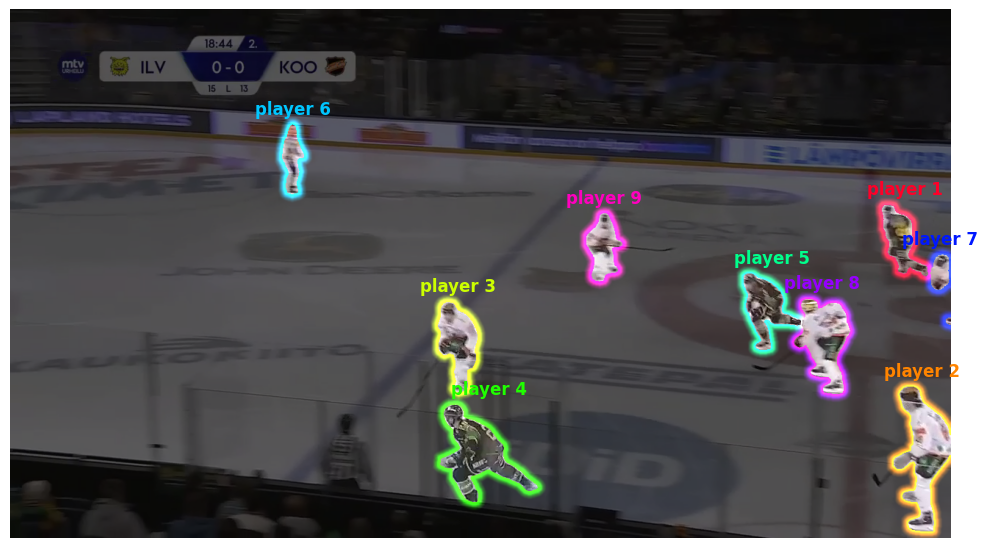

In [27]:
# Load COCO annotations
with open("/content/annotations/train.json", "r") as f:
    coco = json.load(f)

# Build image_id -> annotations mapping
ann_by_image = {}
for ann in coco["annotations"]:
    ann_by_image.setdefault(ann["image_id"], []).append(ann)

def visualize_with_glow(image_info, annotations):
    img_path = os.path.join("/content/frames", image_info["file_name"])
    image = Image.open(img_path)
    img_array = np.array(image)
    img_h, img_w = img_array.shape[:2]

    colors = plt.cm.gist_rainbow(np.linspace(0, 1, len(annotations)))

    # Darkened background
    result = (img_array * 0.4).astype(np.uint8)

    # Decode masks from RLE
    masks = []
    boxes = []
    for ann in annotations:
        mask = mask_utils.decode(ann["segmentation"])
        masks.append(mask)
        # Convert bbox from [x, y, w, h] to [x0, y0, x1, y1]
        x, y, w, h = ann["bbox"]
        boxes.append([x, y, x + w, y + h])

    # Outline/glow for masks
    for idx, mask in enumerate(masks):
        if mask.shape != (img_h, img_w):
            continue

        color = colors[idx][:3]
        color_bgr = (color * 255).astype(np.uint8)
        mask_uint8 = (mask * 255).astype(np.uint8)

        kernel_sizes = [20, 15, 10, 5]
        alphas = [0.2, 0.3, 0.4, 0.8]

        for kernel_size, alpha in zip(kernel_sizes, alphas):
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
            dilated = cv2.dilate(mask_uint8, kernel, iterations=1)
            blurred = cv2.GaussianBlur(dilated, (5, 5), 0)
            colored_glow = np.zeros((img_h, img_w, 3), dtype=np.uint8)
            for c in range(3):
                colored_glow[:, :, c] = (blurred * color[c]).astype(np.uint8)
            result = cv2.addWeighted(result, 1.0, colored_glow, alpha, 0)

    # Brighten masked regions
    for mask in masks:
        if mask.shape != (img_h, img_w):
            continue
        mask_3d = np.stack([mask]*3, axis=-1)
        brightened = (img_array * 1.3).clip(0, 255).astype(np.uint8)
        result = np.where(mask_3d > 0.5, brightened, result).astype(np.uint8)

    # Plot and draw boxes
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(result)

    for idx, box in enumerate(boxes):
        color = colors[idx][:3]
        x0, y0, x1, y1 = box
        rect = Rectangle((x0, y0), x1-x0, y1-y0, linewidth=0, edgecolor=color, facecolor='none')
        ax.add_patch(rect)
        ax.text(x0 + (x1-x0)/2, y0 - 15, f"player {idx+1}",
                bbox=dict(facecolor="none", edgecolor=color, pad=5, linewidth=0),
                fontsize=12, color=color, weight='bold', ha='center')

    ax.axis('off')
    fig.patch.set_facecolor('#fff')
    plt.tight_layout()
    plt.show()

    return result

os.makedirs("/content/frames_processed", exist_ok=True)

for image_info in coco["images"][:5]:
    image_id = image_info["id"]
    anns = ann_by_image.get(image_id, [])
    if not anns:
        continue
    result = visualize_with_glow(image_info, anns)

    # Save processed frame
    output_path = f"/content/frames_processed/frame_{image_id-1:03d}.png"
    cv2.imwrite(output_path, cv2.cvtColor(result, cv2.COLOR_RGB2BGR))